In [5]:
import numpy as np
import matplotlib.pyplot as plt
import bruges
import segyio
from fmu.tools import DomainConversion
from scipy.interpolate import interp1d
from bruges import noise
import time
import ctypes

c:\Users\yuril\AppData\Local\Programs\Python\Python313\Lib\site-packages\bruges\__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [6]:
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, PReLU

In [7]:
import pickle

In [8]:
MODELS_PATH = [r"C:\Users\yuril\Downloads\modelos_105k_512ams_4ms.pkl"]

## Funções

In [9]:
def read_pickle(file_path: str) -> list:
    pickle_in = open(file_path, "rb")
    data = pickle.load(pickle_in)
    pickle_in.close()
    return data

def split(x):
    top,bottom = np.split(x, 2, axis=0)
    resultado = np.zeros(((x.shape[0])//2,x.shape[1]*2))
    for j in range(x.shape[1]):
        for i in range(x.shape[0]//2):
            resultado[i][j*2] = top[i][j]
            resultado[i][(j*2)-1] = bottom[i][j]
    return resultado

def normalizacao(x): #mudar aqui
    vetor_normalizado = np.zeros(x.shape)
    std = np.std(x)
    for i in range(x.shape[1]):
        media = np.mean(x[:,i])
        vetor = (x[:,i])/std
        vetor_normalizado[:,i] = vetor
    return vetor_normalizado

def add_gaussian_noise_global_snr(signal, snr_db, seed=42, eps=1e-12):
    rng = np.random.default_rng(seed)
    signal = signal.astype(np.float32)

    signal_power = float(np.mean(signal**2))
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise_std = np.sqrt(max(noise_power, eps))

    noise = rng.normal(0.0, noise_std, size=signal.shape).astype(np.float32)
    noisy = signal + noise

    measured = 10.0 * np.log10(np.mean(signal*2) / (np.mean(noise*2) + eps))
    return noisy.astype(np.float32), noise.astype(np.float32), float(measured)

    

In [50]:
models_outro = []
for path in MODELS_PATH:
    models_outro += read_pickle(path)

In [51]:
w,t = bruges.filters.ricker(0.064, 0.001, 40)

In [52]:
for i in range(10000):
    if i == 0 :
        vetor_rc = models_outro[i]['rc']
    else:
        ve = models_outro[i]['rc']
        vetor_rc = np.vstack((vetor_rc,ve))
vetor_rc = vetor_rc.T


In [53]:
vetor_rc.shape

(512, 10000)

In [54]:
'''for i in range(10000):
    if i == 0 :
        trace = models_outro[i]['trace']
    else:
        tr = models_outro[i]['trace']
        trace = np.vstack((trace,tr))
trace = trace.T'''

"for i in range(10000):\n    if i == 0 :\n        trace = models_outro[i]['trace']\n    else:\n        tr = models_outro[i]['trace']\n        trace = np.vstack((trace,tr))\ntrace = trace.T"

In [55]:
for i in range(10000):
    rc = models_outro[i]['rc']
    conv = np.convolve(rc, w, mode='same')
    if i == 0:
        trace = conv
    else:
        trace = np.vstack((trace, conv))
trace = trace.T

In [56]:
trace.shape

(512, 10000)

In [57]:
trace_norm = normalizacao(trace)

In [58]:
configs = {
            "modelo":"CNN",
            "activation":"linear",
            "optimizer":"adam",
            "loss":"mse",#tf.keras.losses.CosineSimilarity(axis=-1),
            "metrics":"mae"

}

In [59]:
trace_norm.shape

(512, 10000)

In [60]:

if configs["modelo"] == "CNN":
    X_train = trace_norm
    y_train = vetor_rc

    model = models.Sequential([
        layers.Conv1D(32, 5, activation=configs["activation"], padding='same', input_shape=(512, 1)),
        layers.PReLU(shared_axes=[1]),
        layers.Conv1D(64, 5, activation=configs["activation"], padding='same'),
        layers.PReLU(shared_axes=[1]),
        layers.Conv1D(1, 1, activation='linear', padding='same')
    ])


elif configs["modelo"] == "UNet":
    X_train = trace_norm.T
    y_train = vetor_rc.T

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1) 
    y_train = y_train.reshape(y_train.shape[0], y_train.shape[1], 1)

    inputs = layers.Input(shape=(512, 1))

    c1 = layers.Conv1D(32, 5, activation=configs["activation"], padding='same') (inputs)
    c1 = layers.PReLU(shared_axes=[1])(c1)
    c1 = layers.Dropout(0.2)(c1)
    p1 = layers.MaxPooling1D(2)(c1)

    c2 = layers.Conv1D(64, 5, activation=configs["activation"], padding='same') (p1)
    c2 = layers.PReLU(shared_axes=[1])(c2)
    c2 = layers.Dropout(0.2)(c2)
    p2 = layers.MaxPooling1D(2)(c2)

    c3 = layers.Conv1D(128, 5, activation=configs["activation"], padding='same') (p2)
    c3 = layers.PReLU(shared_axes=[1])(c3)
    c3 = layers.Dropout(0.2)(c3)
    p3 = layers.MaxPooling1D(2)(c3)

    b = layers.Conv1D(256, 5, activation=configs["activation"], padding='same') (p3)
    b = layers.PReLU(shared_axes=[1])(b)
    b = layers.Dropout(0.3)(b)

    u3 = layers.UpSampling1D(2)(b)
    u3 = layers.concatenate ([u3, c3])
    d3 = layers.Conv1D(128, 5, activation=configs["activation"], padding='same') (u3)
    d3 = layers.PReLU(shared_axes=[1])(d3)

    u2 = layers.UpSampling1D(2)(d3)
    u2 = layers.concatenate ([u2, c2])
    d2 = layers.Conv1D(64, 5, activation=configs["activation"], padding='same') (u2)
    d2 = layers.PReLU(shared_axes=[1])(d2)

    u1 = layers.UpSampling1D(2)(d2)
    u1 = layers.concatenate ([u1, c1])
    d1 = layers.Conv1D(32, 5, activation=configs["activation"], padding='same') (u1)
    d1 = layers.PReLU(shared_axes=[1])(d1)

    outputs = layers.Conv1D(1, 1, activation="linear", padding="same") (d1)

    model = models. Model(inputs, outputs, name="UNet1D")


elif configs["modelo"] == "MLP":
    X_train = trace_norm
    y_train = vetor_rc

    model = models.Sequential([
        Dense(32, activation=configs["activation"], input_shape=(512, 1)),
        #layers.PReLU(shared_axes=[1]),
        Dense(64, activation=configs["activation"]),
        #layers.PReLU(shared_axes=[1]),
        Dense(64, activation=configs["activation"]),
        #layers.PReLU(shared_axes=[1]),
        
        Dense(1, activation='linear')
    ])

model.compile(
    optimizer=configs["optimizer"],
    loss=configs["loss"],                 
    metrics=[configs["metrics"]]        
)

In [61]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 512, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_2 (PReLU)               │ (None, 512, 32)        │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 512, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_3 (PReLU)               │ (None, 512, 64)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 512, 1)         │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,657 (41.63 KB)

 Trainable params: 10,657 (41.63 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
callback_parada = EarlyStopping(
    monitor='mae', 
    patience=5,
    restore_best_weights=True 
)

In [63]:
trace_norm.shape

(512, 10000)

In [64]:
inicio = time.time()
history = model.fit(
    X_train,y_train,
    epochs=300, 
    batch_size=32,
    callbacks = [callback_parada],
    validation_split=0.10,
    
)

fim = time.time()
tempo_total = fim - inicio

Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 662ms/step - loss: 0.0108 - mae: 0.0646 - val_loss: 0.0069 - val_mae: 0.0391
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 721ms/step - loss: 0.0077 - mae: 0.0460 - val_loss: 0.0063 - val_mae: 0.0383
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 675ms/step - loss: 0.0073 - mae: 0.0426 - val_loss: 0.0062 - val_mae: 0.0363
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 665ms/step - loss: 0.0072 - mae: 0.0408 - val_loss: 0.0061 - val_mae: 0.0354
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 645ms/step - loss: 0.0071 - mae: 0.0397 - val_loss: 0.0060 - val_mae: 0.0347
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 592ms/step - loss: 0.0070 - mae: 0.0390 - val_loss: 0.0060 - val_mae: 0.0339
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 683ms/step - loss: 0.0070 - mae: 0.0386 - val_loss: 0.0060 - val_mae: 0.0335
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 685ms/step - loss: 0.0070 - mae: 0.0380 - val_loss: 0.0060 - val_mae: 0.0334
Epoch 9/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 11

## Loss

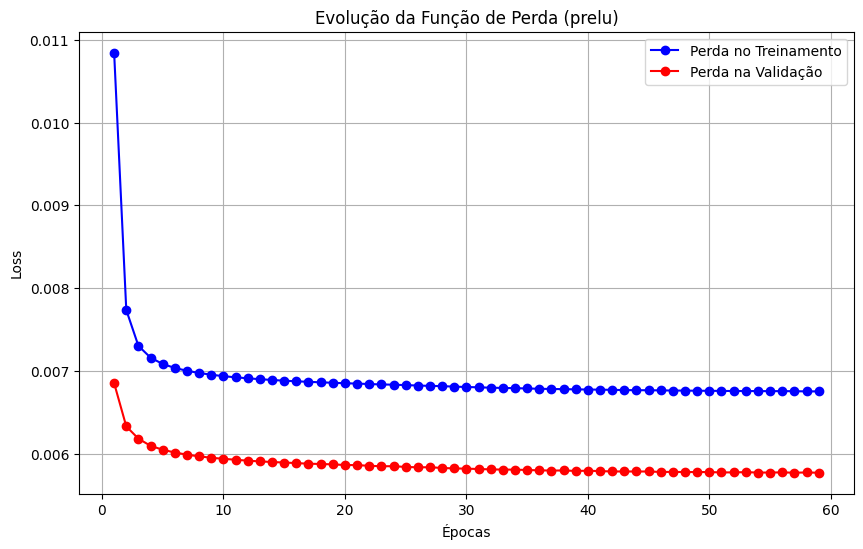

In [65]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Perda no Treinamento')
plt.plot(epochs, val_loss, 'ro-', label='Perda na Validação')

plt.title('Evolução da Função de Perda (prelu)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

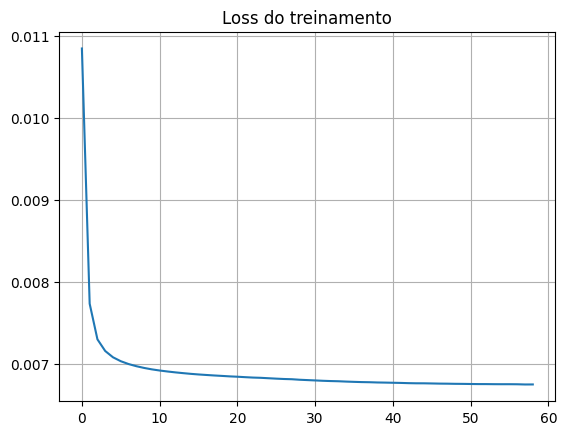

In [66]:
plt.plot(history.history['loss'], label='Training Loss')
plt.title("Loss do treinamento")
plt.grid(True)

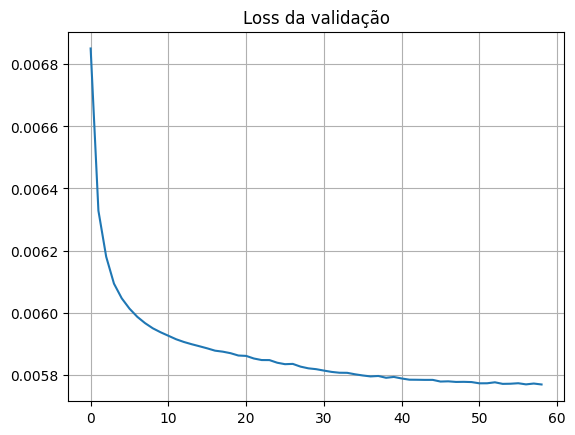

In [67]:
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss da validação")
plt.grid(True)

## Teste Marmousi 1

In [68]:
n_z, n_x = 751,2301

vp_1d = np.fromfile(r"C:\Users\yuril\Downloads\vp.bin", dtype=np.float32)

expected_size = n_z * n_x

print("AI shape:",(n_z,n_x))
print("VP lido/esperado:", vp_1d.size, expected_size)

vp_depth_full = vp_1d.reshape(n_x, n_z).T.astype(np.float32)

print("VP shape:", vp_depth_full.shape)
#print("AI min/max:", float(n_z, n_x))
print("VP min/max:", float(n_z),float(n_x))

AI shape: (751, 2301)
VP lido/esperado: 1728051 1728051
VP shape: (751, 2301)
VP min/max: 751.0 2301.0


In [69]:
dz = 4

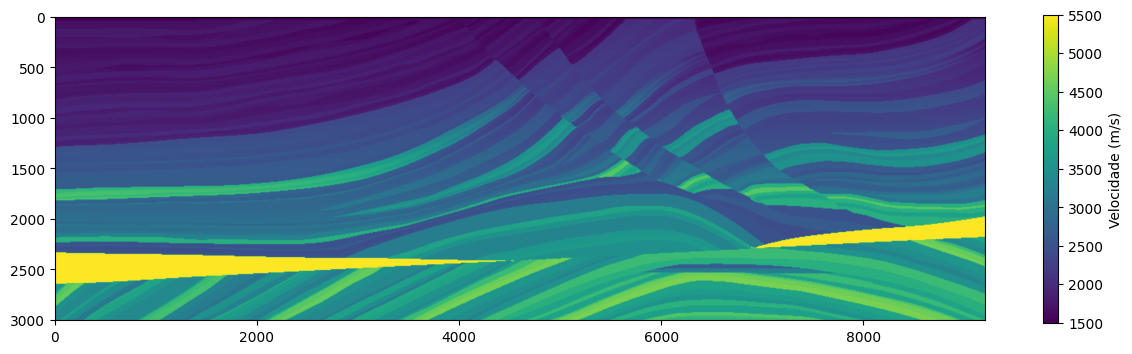

In [70]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(vp_depth_full, extent=[0,n_x*dz,n_z*dz,0])
ax.imshow(vp_depth_full,extent=[0,n_x*dz,n_z*dz,0])

fig.colorbar(plot, ax=ax,shrink = 0.4,label='Velocidade (m/s)')

In [71]:
def dominio_do_tempo(dz,vp,n_x,n_z):

    dt = 2*dz/vp

    t_sum = np.cumsum(dt,0)

    vetor_tempo = np.arange(0,np.max(t_sum),np.max(t_sum)/n_z)
    n_t = len(vetor_tempo)

    tmax_values = []
    twt_cube = np.zeros_like(vp)

    for i in range(n_x):
        vp_coluna = vp[:, i]

        dz_array = np.full_like(vp_coluna, dz)

        vp_valido = np.where(vp_coluna > 0, vp_coluna, np.nan)

        dt1 = dz_array / vp_valido
        twt = 2 * np.nancumsum(dt1)


        twt_cube[:, i] = twt    
        tmax_values.append(twt[-1])

    cubo = twt_cube
    return cubo

In [72]:
cubo = dominio_do_tempo(4,vp_depth_full,n_x,n_z)

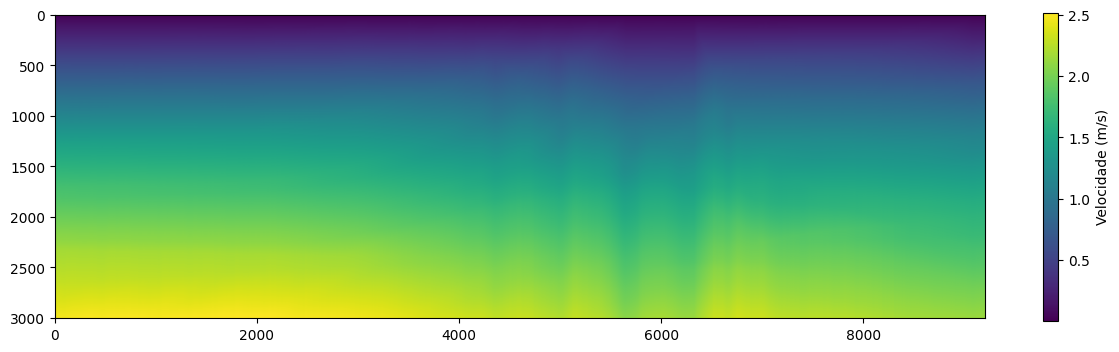

In [73]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(cubo, extent=[0,n_x*dz,n_z*dz,0])
ax.imshow(cubo,extent=[0,n_x*dz,n_z*dz,0])

fig.colorbar(plot, ax=ax,shrink = 0.4,label='Velocidade (m/s)')


In [74]:
den_1d = np.fromfile(r"C:\Users\yuril\Downloads\rho.bin", dtype=np.float32)

densidade = vp_1d.reshape(n_x, n_z).T.astype(np.float32) 


In [75]:
Imp = cubo*densidade
Ref = (Imp[1:,:] - Imp[0:-1,:])/(Imp[1:,:] + Imp[0:-1,:])

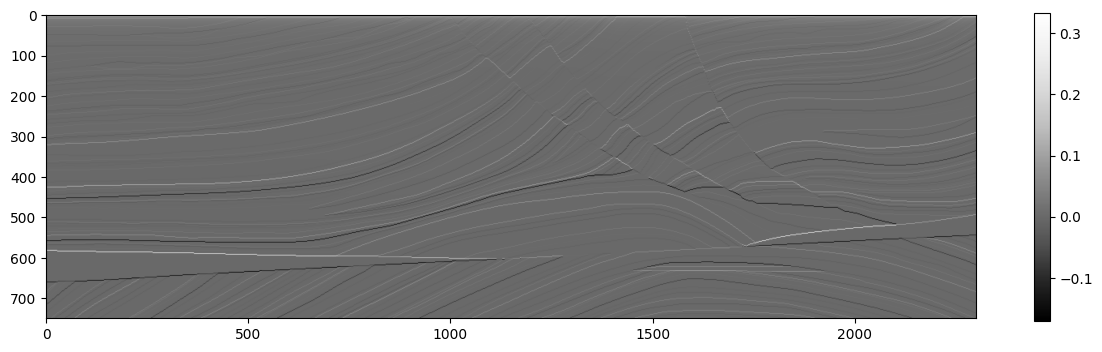

In [76]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(Ref,cmap = "Grays_r")
ax.imshow(Ref,cmap = "Grays_r")

fig.colorbar(plot, ax=ax,shrink = 0.4)

In [77]:
#traco  = np.array(bruges.filters.convolve(Ref,w))

traco_m = np.array([np.convolve(Ref[:,i],w,mode='same') for i in range(Ref.shape[1])]).T

In [78]:
traco_m.shape

(750, 2301)

In [79]:
traco_m_norm, noise, measured_snr = add_gaussian_noise_global_snr(normalizacao(traco_m),5)

In [80]:
traco_m_norm.shape

(750, 2301)

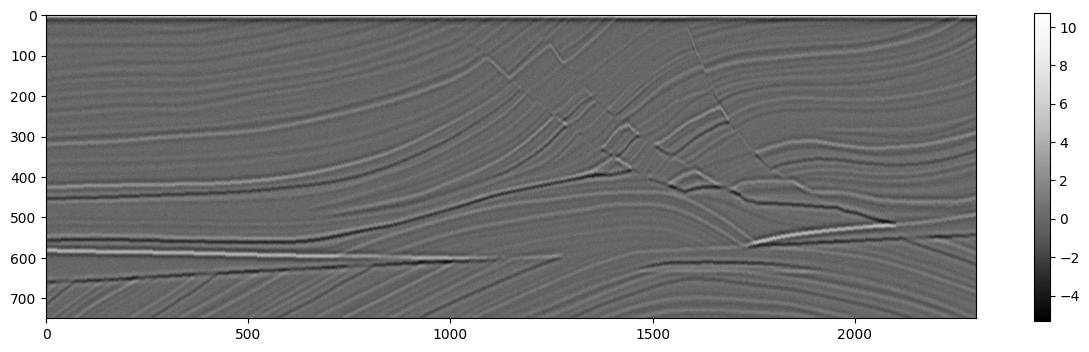

In [81]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(traco_m_norm,cmap = "Grays_r")
plot
fig.colorbar(plot, ax=ax,shrink = 0.4)

In [82]:
if configs["modelo"] == "CNN":
    predicao_marmousi = model.predict(traco_m_norm)

elif configs["modelo"] == "UNet":
    print(traco_m_norm.shape)
    p1 = traco_m_norm[:,:512]
    p2 = traco_m_norm[:,237:]

    pred1 = model.predict(p1)
    pred2 = model.predict(p2)
    complemento = pred2[:,275:,:]

    predicao_marmousi = np.hstack((pred1, complemento))

elif configs["modelo"] == "MLP":
    predicao_marmousi = model.predict(traco_m_norm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [83]:
predicao_marmousi.shape

(750, 2301, 1)

In [84]:

if configs["modelo"] == "UNet":
    predicao_marmousi = np.squeeze(predicao_marmousi)


## Resultado

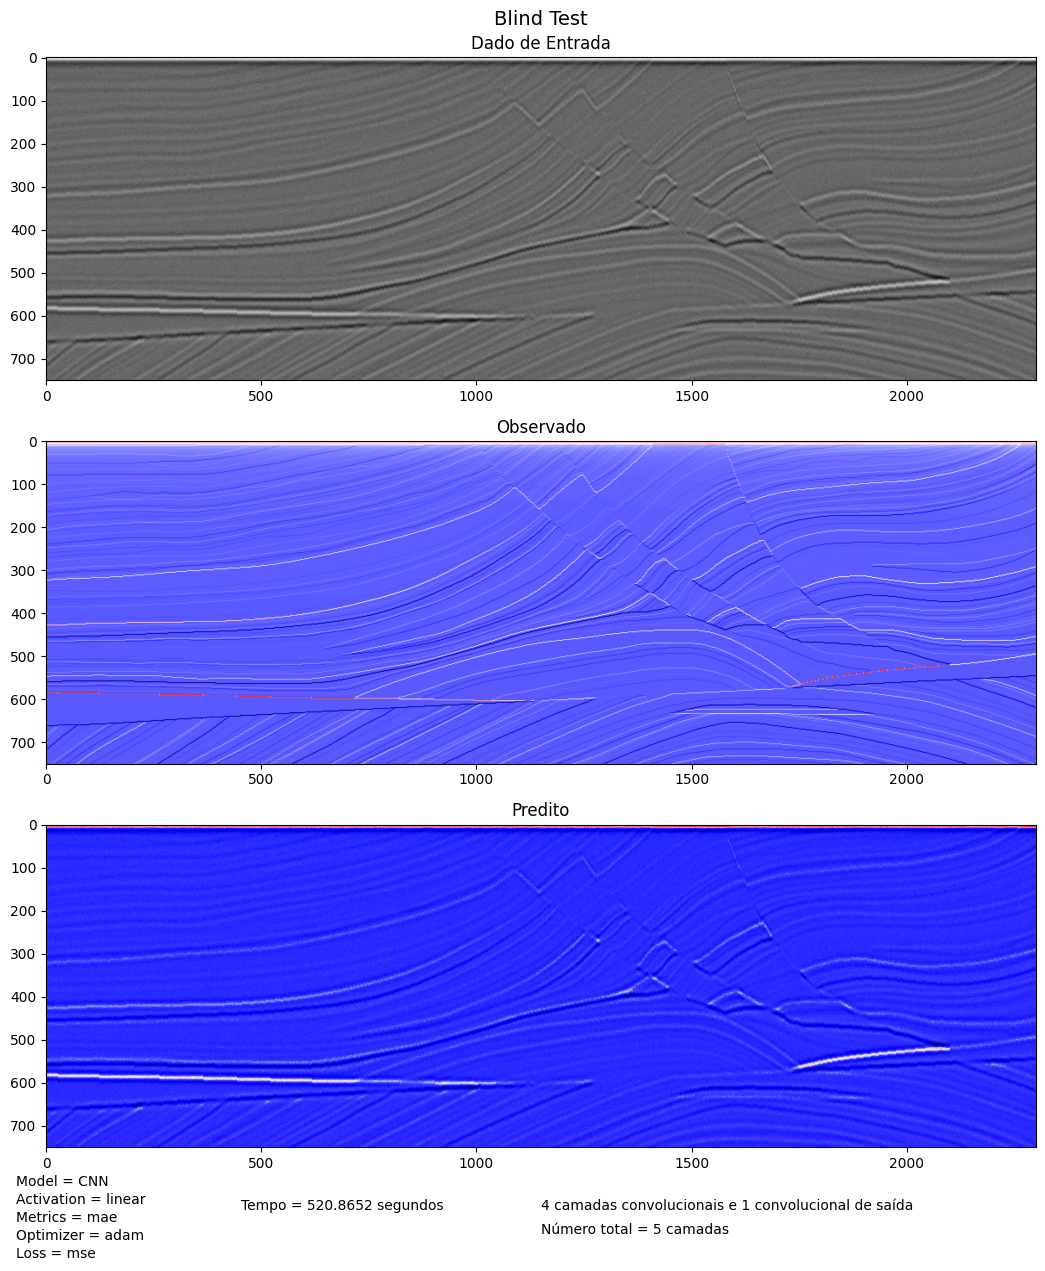

In [85]:
fig, ax = plt.subplots(3,1,figsize = (15,12))
fig.suptitle("Blind Test",fontsize = 14)
ax[0].imshow(traco_m_norm,cmap = "Grays_r")
ax[0].set_title("Dado de Entrada")

ax[1].imshow(Ref,cmap = "seismic")
ax[1].set_title("Observado")

ax[2].imshow(predicao_marmousi,cmap = "seismic")
ax[2].set_title("Predito")

fig.text(0.15, 0.0, f'Model = {configs["modelo"]}')
fig.text(0.15, -0.015, f'Activation = {configs["activation"]}')
#fig.text(0.15, -0.015, f'Activation = PRElu')
fig.text(0.15, -0.06, f'Loss = {configs["loss"]}')
#fig.text(0.15, -0.06, f'Loss = Cossine_Similarity')
fig.text(0.15, -0.03, f'Metrics = {configs["metrics"]}')
fig.text(0.15, -0.045, f'Optimizer = {configs["optimizer"]}')
fig.text(0.3, -0.02, f'Tempo = {round(tempo_total,4)} segundos')

if configs["modelo"] == "CNN":
    fig.text(0.5, -0.02, f'{len(model.layers)-1} camadas convolucionais e 1 convolucional de saída')
    fig.text(0.5, -0.04, f'Número total = {len(model.layers)} camadas')
elif configs["modelo"] == "UNet":
    fig.text(0.48, -0.02, f'Número de camadas = {len(model.layers)-2} + 1 de saída e 1 de entrada')
plt.tight_layout()


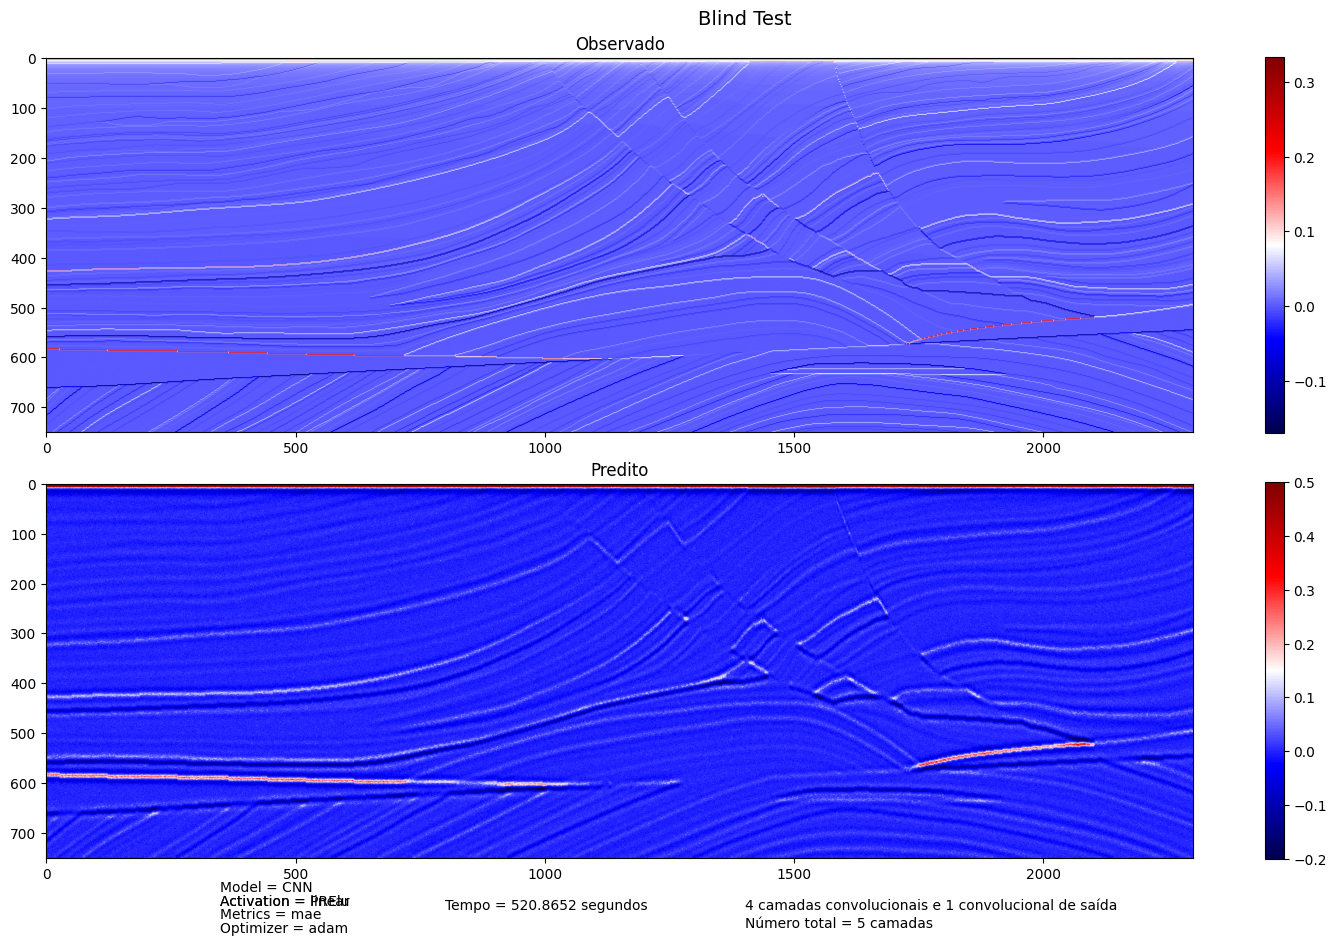

In [93]:
fig, ax = plt.subplots(2,1,figsize = (15,9))
fig.suptitle("Blind Test",fontsize = 14)
plot1 = ax[0].imshow(Ref,cmap = "seismic")
ax[0].set_title("Observado")
plt.colorbar(plot1)

plot2 = ax[1].imshow(predicao_marmousi,vmin = -0.2, vmax = 0.5, cmap = "seismic")
ax[1].set_title("Predito")
plt.colorbar(plot2)

fig.text(0.15, 0.0, f'Model = {configs["modelo"]}')
fig.text(0.15, -0.015, f'Activation = {configs["activation"]}')
fig.text(0.15, -0.015, f'Activation = PRElu')
#fig.text(0.15, -0.06, f'Loss = {configs["loss"]}')
#fig.text(0.15, -0.06, f'Loss = Cossine_Similarity')
fig.text(0.15, -0.03, f'Metrics = {configs["metrics"]}')
fig.text(0.15, -0.045, f'Optimizer = {configs["optimizer"]}')
fig.text(0.3, -0.02, f'Tempo = {round(tempo_total,4)} segundos')

if configs["modelo"] == "CNN":
    fig.text(0.5, -0.02, f'{len(model.layers)-1} camadas convolucionais e 1 convolucional de saída')
    fig.text(0.5, -0.04, f'Número total = {len(model.layers)} camadas')
elif configs["modelo"] == "UNet":
    fig.text(0.48, -0.02, f'Número de camadas = {len(model.layers)-2} + 1 de saída e 1 de entrada')
plt.tight_layout()


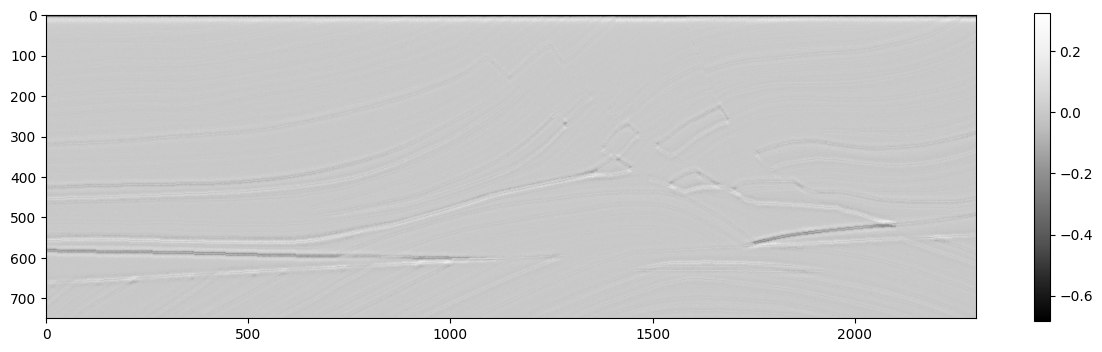

In [87]:
Perda_de_amplitude = Ref - np.squeeze(predicao_marmousi)
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(Perda_de_amplitude,cmap = "Grays_r")
plot
fig.colorbar(plot, ax=ax,shrink = 0.4)

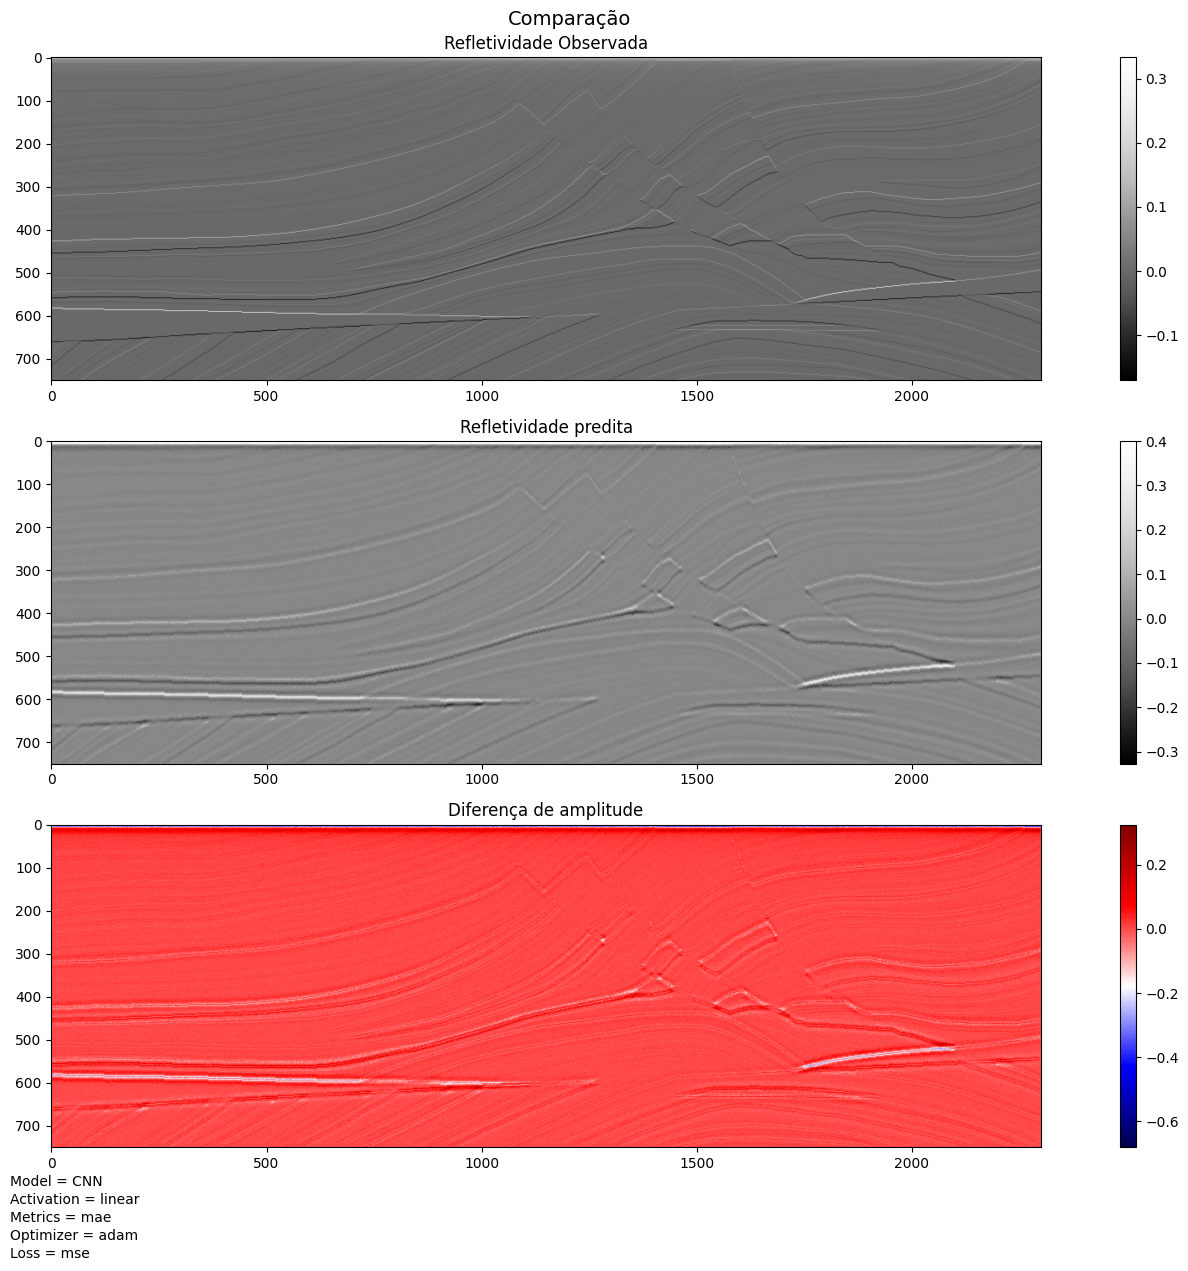

In [90]:
fig, ax = plt.subplots(3,1,figsize = (16,12))
fig.suptitle("Comparação",fontsize = 14)
plot1 = ax[0].imshow(Ref,cmap = "Grays_r")
ax[0].set_title("Refletividade Observada")
plt.colorbar(plot1)

plot2 = ax[1].imshow(predicao_marmousi,vmax = 0.4,cmap = "Grays_r")
ax[1].set_title("Refletividade predita")
plt.colorbar(plot2)

plot3 = ax[2].imshow(Perda_de_amplitude, cmap = "seismic")
ax[2].set_title("Diferença de amplitude")
plt.colorbar(plot3)
fig.text(0.15, 0.0, f'Model = {configs["modelo"]}')
fig.text(0.15, -0.015, f'Activation = {configs["activation"]}')
#fig.text(0.15, -0.015, f'Activation = PRElu')
fig.text(0.15, -0.06, f'Loss = {configs["loss"]}')
fig.text(0.15, -0.03, f'Metrics = {configs["metrics"]}')
fig.text(0.15, -0.045, f'Optimizer = {configs["optimizer"]}')

plt.tight_layout()


In [92]:
ctypes.windll.user32.MessageBoxW(0, "The program has finished successfully!", "Program Status", 0)

1